# 3 · Searching the space

The small space can be simulated exhaustively, larger ones cannot. Here the search gets a budget of simulations, and we compare what it finds with the optimum we know from simulating everything.

In [1]:
# This is just the code header, ignore it.
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dse
import dse.plots as plots
from dse import DATA, WORK

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

In [2]:
mlir = DATA / "small" / "gemv.mlir"
oracle = dse.load_pool(DATA / "small" / "pool.csv")
best = oracle["cost"].min()

# Random search needs no simulator once the oracle exists; 2000 trials of it
# give the reference every search below is measured against.
baseline = dse.random_search_baseline(oracle, budget=100)

## 40 simulations

Cinnamon searches with Bayesian optimisation. After a random initial sample, a surrogate model predicts the latency (µ) and the uncertainty of that prediction (σ) for the configurations not simulated yet. The next configuration to simulate is chosen from these predictions.

In [3]:
max_evals = 40
run = dse.bo(mlir, f"bo{max_evals}", max_evals=max_evals, n_init=10)
bo_pool = run.pool()
v = dse.visited(bo_pool)

print(f"{len(v)} simulations in {run.seconds:.1f} s")
print(f"best found {v['cost'].min():.3f} ms — rank {dse.rank_of(v['cost'].min(), oracle)} of {len(oracle)}")

40 simulations in 6.8 s                                                                             
best found 2.165 ms — rank 9 of 3234


The configurations the search simulated, in order. The first 10 are the random initial sample. For the others, `mu` and `sigma` are what the surrogate predicted before they were simulated, and `acq` is the score that selected them.

In [4]:
cols = ["eval_iter"] + dse.param_columns(bo_pool) + ["cost", "mu", "sigma", "acq"]
v[cols].style.format({"cost": "{:.2f}", "mu": "{:.2f}", "sigma": "{:.2f}", "acq": "{:.2f}"}).hide(axis="index")

eval_iter,dpus,tasklets,gemv.M.mram,gemv.M.wram,gemv.K.mram,gemv.K.wram,gemv.order[0],gemv.order[1],cost,mu,sigma,acq
0,64,8,128,128,16,8,2,1,8.30,0.92,0.01,0.91
1,64,4,32,32,128,64,2,1,9.18,0.96,0.00,0.96
2,64,8,128,4,16,2,1,2,8.57,0.94,0.01,0.92
3,64,1,64,64,256,1,1,2,15.57,1.21,0.03,1.14
4,64,1,64,1,256,256,1,2,15.10,1.18,0.01,1.16
5,64,2,128,32,64,64,2,1,11.12,1.05,0.01,1.04
6,64,1,1024,256,16,4,2,1,15.11,1.19,0.02,1.15
7,64,4,128,8,32,32,1,2,9.28,0.97,0.01,0.95
8,64,8,4,4,512,16,1,2,8.57,0.93,0.00,0.93
9,64,16,16,16,64,32,1,2,8.05,0.91,0.00,0.90


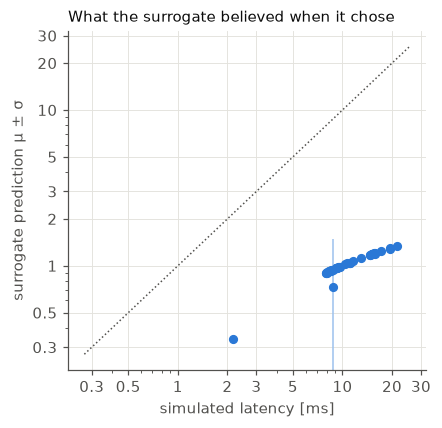

In [5]:
plots.surrogate_check(bo_pool)
plt.show()

Points on the dotted line were predicted correctly. The bars show the predicted uncertainty.

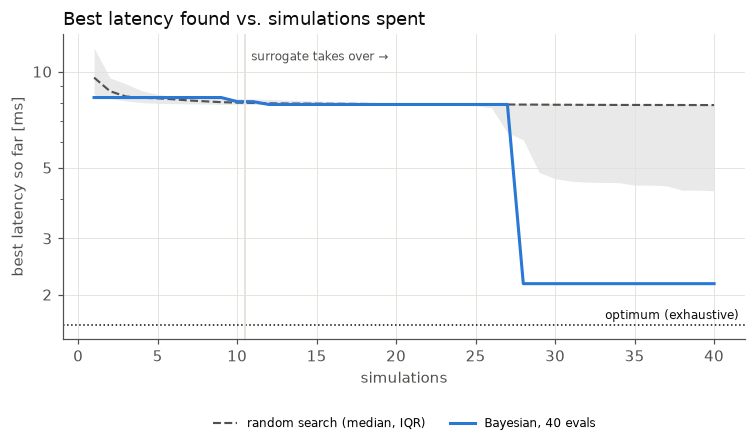

In [6]:
ax = plots.best_so_far({"Bayesian, 40 evals": bo_pool}, oracle_best=best,
                       baseline=baseline[:, :max_evals], n_init=10)
plt.show()

## Several seeds

The search is randomised. Running it from 5 seeds shows how much the result depends on the seed.

In [7]:
r5 = dse.bo(mlir, f"bo{max_evals}x5", max_evals=max_evals, n_init=10, seeds=5)
pools_seeds = r5.pools()

print(f"5 × {max_evals} simulations in {r5.seconds:.0f} s")
for seed, p in sorted(pools_seeds.items()):
    m = dse.visited(p)["cost"].min()
    print(f"seed {seed:4d}: best {m:6.3f} ms  rank {dse.rank_of(m, oracle):4d}  ({(m / best - 1) * 100:4.0f} % above optimum)")

5 × 40 simulations in 24 s                                                                          
seed   42: best  2.165 ms  rank    9  (  35 % above optimum)
seed   73: best  2.708 ms  rank   18  (  69 % above optimum)
seed  104: best  6.553 ms  rank   34  ( 308 % above optimum)
seed  135: best  1.668 ms  rank    6  (   4 % above optimum)
seed  166: best  4.494 ms  rank   27  ( 180 % above optimum)


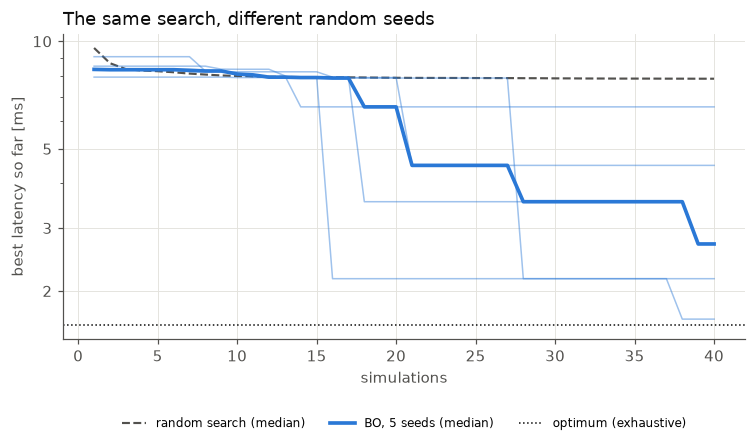

In [8]:
ax = plots.seeds_spread(pools_seeds, oracle_best=best, baseline=baseline[:, :max_evals])
plt.show()

Finidng the best configurations depends in part on the random seed.

## 100 simulations

100 simulations in 16.2 s — best 1.604 ms, rank 1                                                   


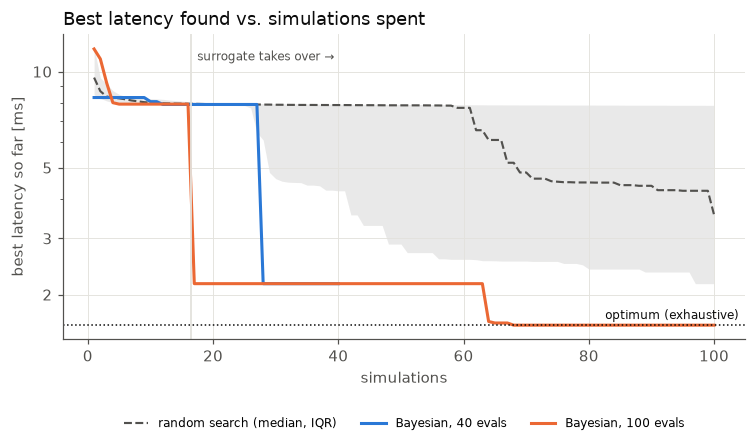

In [26]:
r100 = dse.bo(mlir, "bo100", max_evals=100, n_init=16)
pool100 = r100.pool()
m = dse.visited(pool100)["cost"].min()
print(f"100 simulations in {r100.seconds:.1f} s — best {m:.3f} ms, rank {dse.rank_of(m, oracle)}")

ax = plots.best_so_far({f"Bayesian, {max_evals} evals": bo_pool, "Bayesian, 100 evals": pool100},
                       oracle_best=best, baseline=baseline, n_init=16)
plt.show()

With a larger budget the search finds the optimum more often. Random search with the same budget (dashed) stays well above it.

## A larger space

4096 × 4096 on up to 2048 DPUs, so the number of DPUs is a parameter too. We simulated its 26,238 feasible configurations in advance (7 minutes on 14 cores).

In [ ]:
big_mlir = DATA / "big" / "gemv.mlir"
big_oracle = dse.load_pool(DATA / "big" / "pool.csv")
big_space = dse.load_space(DATA / "big" / "space.json")
big_best = big_oracle["cost"].min()

print(dse.cinm.describe_space(big_space, feasible=True))
print()
print(f"best {big_best:.2f} ms, median {big_oracle['cost'].median():.1f} ms; "
      f"within 10 % of the best: {(big_oracle['cost'] <= 1.1 * big_best).sum()} configurations")

Cartesian product: 180,101,000,000,000 combinations
Feasible:          26,238 configurations (1.5e-08 %)
Built in 0.23 s by the constraint solver (52,741 search nodes)

best 7.02 ms, median 125.4 ms; within 10 % of the best: 10 configurations


In [18]:
rb = dse.bo(big_mlir, "big_bo", max_evals=100, n_init=20)
poolb = rb.pool()
mb = dse.visited(poolb)["cost"].min()
big_baseline = dse.random_search_baseline(big_oracle, budget=100)

print(f"100 simulations in {rb.seconds:.1f} s")
print(f"best found {mb:.2f} ms — rank {dse.rank_of(mb, big_oracle)} of {len(big_oracle)}, "
      f"{(mb / big_best - 1) * 100:.0f} % above the optimum")
print(f"random search, same budget: median {np.median(big_baseline[:, -1]):.1f} ms "
      f"({(np.median(big_baseline[:, -1]) / big_best - 1) * 100:.0f} % above)")

100 simulations in 18.8 s                                                                           
best found 7.19 ms — rank 2 of 26238, 2 % above the optimum
random search, same budget: median 46.1 ms (556 % above)


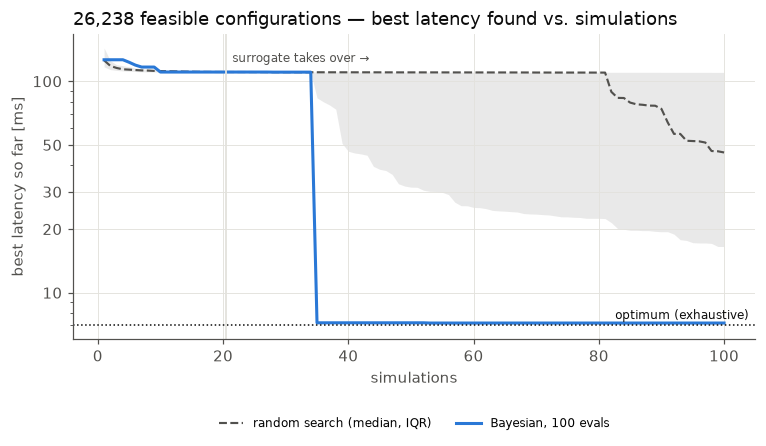

In [19]:
ax = plots.best_so_far({"Bayesian, 100 evals": poolb}, oracle_best=big_best,
                       baseline=big_baseline, n_init=20,
                       title="26,238 feasible configurations — best latency found vs. simulations")
plt.show()

In [20]:
cols = dse.param_columns(big_oracle) + ["cost"]
big_oracle.sort_values("cost").head(5)[cols].style.format({"cost": "{:.3f}"}).hide(axis="index")

dpus,tasklets,gemv.M.mram,gemv.M.wram,gemv.K.mram,gemv.K.wram,gemv.order[0],gemv.order[1],cost
2048,1,2,2,4096,4096,1,2,7.025
2048,1,2,1,4096,4096,1,2,7.190
2048,1,2,1,4096,2048,1,2,7.209
2048,1,2,1,4096,1024,1,2,7.238
2048,1,2,1,4096,256,1,2,7.249


Here the best configuration uses 1 tasklet on 2048 DPUs. For the small problem it was 8 tasklets on 64 DPUs.

## Extra: gemm

A matrix–matrix product: 9 parameters and 2.8 million feasible configurations. We have no oracle for this one.

In [21]:
gemm_mlir = DATA / "large" / "gemm.mlir"
gemm_space = dse.dump_space(gemm_mlir, "gemm_space")
print(dse.cinm.describe_space(gemm_space))
print(f"\nAt 60 ms per simulation, enumerating it would take "
      f"{gemm_space['feasible_size'] * 0.06 / 3600:.0f} hours on one core.")

Cartesian product: 2,828,560,000,000,000,000 combinations

At 60 ms per simulation, enumerating it would take 47 hours on one core.


60 simulations in 25.9 s                                                                            


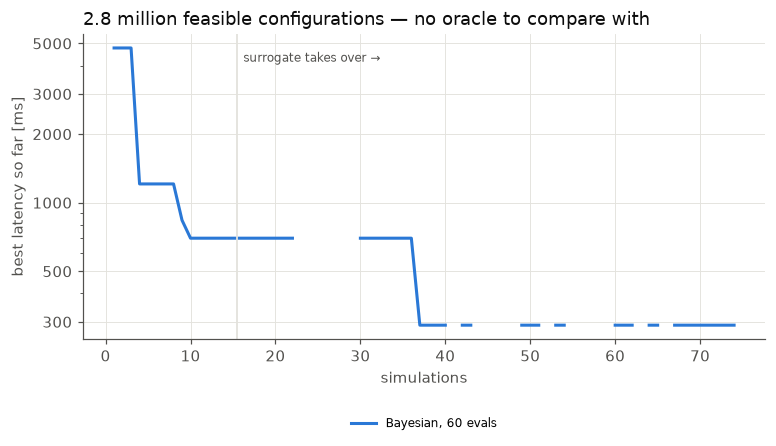

dpus,tasklets,gemm.M.mram,gemm.M.wram,gemm.N.mram,gemm.N.wram,gemm.K.mram,gemm.K.wram,gemm.order[0],gemm.order[1],gemm.order[2],cost
2048,16,1,1,2048,2,128,64,2,3,1,290.11
2048,8,512,16,2,1,512,64,2,3,1,486.63
2048,8,16,1,128,4,256,256,2,3,1,602.34


In [22]:
rl = dse.bo(gemm_mlir, "gemm_bo", max_evals=60, n_init=15)
pooll = rl.pool()
vl = dse.visited(pooll)

print(f"60 simulations in {rl.seconds:.1f} s")
ax = plots.best_so_far({"Bayesian, 60 evals": pooll}, n_init=15,
                       title="2.8 million feasible configurations — no oracle to compare with")
plt.show()

vl.sort_values("cost").head(3)[dse.param_columns(pooll) + ["cost"]].style.format({"cost": "{:.2f}"}).hide(axis="index")

Without an oracle we cannot tell how close this is to the optimum. The two previous spaces show how well the search does with a similar budget when we can check.